# 🚀 Olist Data Warehouse - Complete EDA Analysis

**EXECUTION ORDER GUIDE:**

Before running this notebook, ensure you have completed these steps:

## 📋 Prerequisites Checklist

1. ✅ **PostgreSQL Setup**
   - PostgreSQL 13+ installed and running on port 5432
   - Database `olist_datawarehouse` created
   
2. ✅ **Python Environment**|
   - Python 3.8+ installed
   - All dependencies installed: `pip install -r ../requirements.txt`
   
3. ✅ **Data Files**
   - All Olist CSV files in `../data/` folder
   - Files should include: customers, orders, order_items, payments, reviews, products, sellers
   
4. ✅ **Configuration**
   - Environment file `../src/.env` with database credentials

## ⚡ Quick Start Commands

```bash
# 1. Install dependencies
pip install pandas numpy psycopg2-binary python-dotenv matplotlib seaborn jupyter

# 2. Create database (if needed)
psql -U postgres -c "CREATE DATABASE olist_datawarehouse;"

# 3. Run this notebook (execute cells 1 → final)
```

**⚠️ IMPORTANT: Run cells sequentially from top to bottom!**

# 0. Environment Setup & Database Connection Test

First, let's verify that everything is properly configured before proceeding with the analysis.

In [ ]:
# Environment Setup and Database Connection Verification
import os
import sys
from pathlib import Path

print("🔧 ENVIRONMENT SETUP")
print("=" * 50)

# Check Python version
print(f"Python Version: {sys.version}")
print(f"Current Directory: {os.getcwd()}")

# Check if data folder exists
data_path = Path('../data')
env_path = Path('../src/.env')

print(f"Data Folder Exists: {'✅' if data_path.exists() else '❌'} {data_path.absolute()}")
print(f"Environment File: {'✅' if env_path.exists() else '❌'} {env_path.absolute()}")

# Try importing required packages
required_packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'psycopg2', 'dotenv']
missing_packages = []

for package in required_packages:
    try:
        if package == 'psycopg2':
            import psycopg2
        elif package == 'dotenv':
            from dotenv import load_dotenv
        else:
            __import__(package)
        print(f"✅ {package}")
    except ImportError:
        print(f"❌ {package} - MISSING")
        missing_packages.append(package)

if missing_packages:
    print(f"\n⚠️ Missing packages: {missing_packages}")
    print("Install with: pip install " + " ".join(missing_packages))
else:
    print("\n🎉 All required packages are available!")

In [ ]:
# Database Connection Test
print("\n🔌 DATABASE CONNECTION TEST")
print("=" * 50)

try:
    from dotenv import load_dotenv
    import psycopg2
    
    # Load environment variables
    env_loaded = load_dotenv('../src/.env')
    print(f"Environment loaded: {'✅' if env_loaded else '❌'}")
    
    # Get connection parameters - strip quotes if present
    def clean_env_value(value):
        if value and isinstance(value, str):
            return value.strip().strip("'\"")
        return value
    
    db_config = {
        'host': clean_env_value(os.getenv('DB_HOST', 'localhost')),
        'port': clean_env_value(os.getenv('DB_PORT', '5432')),
        'database': clean_env_value(os.getenv('DB_NAME', 'olist_datawarehouse')), 
        'user': clean_env_value(os.getenv('DB_USER', 'postgres')),
        'password': clean_env_value(os.getenv('DB_PASSWORD'))
    }
    
    print(f"Host: {db_config['host']}")
    print(f"Port: {db_config['port']}")
    print(f"Database: {db_config['database']}")
    print(f"User: {db_config['user']}")
    print(f"Password: {'***' if db_config['password'] else 'NOT SET'}")
    
    # Test connection
    print("\n🔍 Testing connection...")
    conn = psycopg2.connect(**db_config)
    cursor = conn.cursor()
    
    # Get PostgreSQL version
    cursor.execute("SELECT version();")
    version = cursor.fetchone()[0]
    print(f"✅ Connected successfully!")
    print(f"PostgreSQL: {version.split(',')[0]}")
    
    # Check if schemas exist
    cursor.execute("""
        SELECT schema_name 
        FROM information_schema.schemata 
        WHERE schema_name IN ('staging', 'dimensions', 'facts', 'marts')
        ORDER BY schema_name;
    """)
    schemas = [row[0] for row in cursor.fetchall()]
    
    if schemas:
        print(f"Available schemas: {schemas}")
    else:
        print("⚠️ Data warehouse schemas not found - will be created during ETL")
    
    cursor.close()
    conn.close()
    
    print("✅ Database connection test PASSED!")
    
except ImportError as e:
    print(f"❌ Missing Python packages: {e}")
    print("Install with: pip install psycopg2-binary python-dotenv")
    
except psycopg2.OperationalError as e:
    print(f"❌ Database connection FAILED: {e}")
    print("\n🔧 Troubleshooting steps:")
    print("1. Ensure PostgreSQL is running: pg_ctl status")
    print("2. Create database: psql -U postgres -c \"CREATE DATABASE olist_datawarehouse;\"")
    print("3. Check credentials in ../src/.env file")
    print("4. Verify PostgreSQL is listening on port 5432")
    
except Exception as e:
    print(f"❌ Unexpected error: {e}")

print("\n" + "="*50)

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("📂 Current working directory:", os.getcwd())
print("🗂️ Expected data folder:", os.path.abspath('../data/'))

In [19]:
data_folder = '../data/'
all_files = os.listdir(data_folder)
print("Available datasets:")
for i, file in enumerate(all_files, 1):
    print(f"{i}. {file}")

Available datasets:
1. olist_customers_dataset.csv
2. olist_geolocation_dataset.csv
3. olist_orders_dataset.csv
4. olist_order_items_dataset.csv
5. olist_order_payments_dataset.csv
6. olist_order_reviews_dataset.csv
7. olist_products_dataset.csv
8. olist_sellers_dataset.csv
9. product_category_name_translation.csv


In [20]:
# Load all datasets and standardize column names
datasets = {}
for file in all_files:
    df = pd.read_csv(os.path.join(data_folder, file))
    # Standardize column names
    df.columns = [col.strip().lower().replace('"', '') for col in df.columns]
    # Remove file extension for dataset name
    dataset_name = file.replace('.csv', '').replace('olist_', '')
    datasets[dataset_name] = df
    print(f"✓ Loaded {dataset_name}: {df.shape}")

✓ Loaded customers_dataset: (99441, 5)
✓ Loaded geolocation_dataset: (1000163, 5)
✓ Loaded geolocation_dataset: (1000163, 5)
✓ Loaded orders_dataset: (99441, 8)
✓ Loaded order_items_dataset: (112650, 7)
✓ Loaded orders_dataset: (99441, 8)
✓ Loaded order_items_dataset: (112650, 7)
✓ Loaded order_payments_dataset: (103886, 5)
✓ Loaded order_payments_dataset: (103886, 5)
✓ Loaded order_reviews_dataset: (99224, 7)
✓ Loaded products_dataset: (32951, 9)
✓ Loaded sellers_dataset: (3095, 4)
✓ Loaded product_category_name_translation: (71, 2)
✓ Loaded order_reviews_dataset: (99224, 7)
✓ Loaded products_dataset: (32951, 9)
✓ Loaded sellers_dataset: (3095, 4)
✓ Loaded product_category_name_translation: (71, 2)


# 1. Dataset Overview and Structure Analysis

Let's examine each dataset's structure, size, and key characteristics to understand the business model.

In [8]:
# Dataset structure overview
def analyze_dataset_structure():
    print("=" * 80)
    print("DATASET STRUCTURE ANALYSIS")
    print("=" * 80)
    
    for name, df in datasets.items():
        print(f"\n📊 {name.upper()} Dataset:")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        print(f"   Data Types: {df.dtypes.value_counts().to_dict()}")
        print(f"   Missing Values: {df.isnull().sum().sum()}")
        
        # Check for potential primary keys
        for col in df.columns:
            if 'id' in col.lower():
                unique_ratio = df[col].nunique() / len(df)
                print(f"   {col} uniqueness: {unique_ratio:.2%} ({df[col].nunique()} unique)")

analyze_dataset_structure()

DATASET STRUCTURE ANALYSIS

📊 CUSTOMERS_DATASET Dataset:
   Shape: (99441, 5)
   Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
   Data Types: {dtype('O'): 4, dtype('int64'): 1}
   Missing Values: 0
   customer_id uniqueness: 100.00% (99441 unique)
   customer_unique_id uniqueness: 96.64% (96096 unique)

📊 GEOLOCATION_DATASET Dataset:
   Shape: (1000163, 5)
   Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
   Data Types: {dtype('float64'): 2, dtype('O'): 2, dtype('int64'): 1}
   Missing Values: 0

📊 ORDERS_DATASET Dataset:
   Shape: (99441, 8)
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
   Data Types: {dtype('O'): 8}
   Missing Values: 4908
   order_id uniqueness: 100.00% (99441 unique)
   custom

# 1.1. Order Items Detailed Analysis

Deep dive into order_items_dataset to understand the order_item_id sequential numbering pattern.

In [ ]:
# Detailed analysis of order_items_dataset
def analyze_order_items_detailed():
    print("=" * 80)
    print("ORDER ITEMS DETAILED ANALYSIS")
    print("=" * 80)
    
    if 'order_items_dataset' in datasets:
        items_df = datasets['order_items_dataset'].copy()
        
        print(f"📦 ORDER ITEMS STRUCTURE:")
        print(f"   Total Records: {len(items_df):,}")
        print(f"   Columns: {list(items_df.columns)}")
        print(f"   Sample Data:")
        print(items_df.head())
        
        # Analyze order_item_id pattern
        if 'order_item_id' in items_df.columns:
            print(f"\n🔢 ORDER_ITEM_ID ANALYSIS:")
            print(f"   Value Range: {items_df['order_item_id'].min()} to {items_df['order_item_id'].max()}")
            print(f"   Unique Values: {items_df['order_item_id'].nunique()}")
            print(f"   Value Distribution:")
            item_id_dist = items_df['order_item_id'].value_counts().sort_index()
            for item_id, count in item_id_dist.head(10).items():
                print(f"     Item ID {item_id}: {count:,} occurrences")
        
        # Analyze items per order
        print(f"\n📊 ITEMS PER ORDER ANALYSIS:")
        items_per_order = items_df.groupby('order_id')['order_item_id'].count()
        print(f"   Average items per order: {items_per_order.mean():.2f}")
        print(f"   Max items in single order: {items_per_order.max()}")
        print(f"   Orders with multiple items: {(items_per_order > 1).sum():,} ({(items_per_order > 1).sum()/len(items_per_order)*100:.1f}%)")
        
        # Check sequential pattern within orders
        print(f"\n🔄 SEQUENTIAL PATTERN ANALYSIS:")
        sample_orders = items_df['order_id'].unique()[:5]
        for order_id in sample_orders:
            order_items = items_df[items_df['order_id'] == order_id]['order_item_id'].sort_values()
            print(f"   Order {order_id}: item_ids = {list(order_items)}")
        
        # Validate sequential numbering
        sequential_violations = 0
        for order_id in items_df['order_id'].unique():
            order_items = items_df[items_df['order_id'] == order_id]['order_item_id'].sort_values().tolist()
            expected_sequence = list(range(1, len(order_items) + 1))
            if order_items != expected_sequence:
                sequential_violations += 1
        
        print(f"\n✅ SEQUENTIAL INTEGRITY:")
        print(f"   Total Orders: {items_df['order_id'].nunique():,}")
        print(f"   Orders with correct sequential numbering: {items_df['order_id'].nunique() - sequential_violations:,}")
        print(f"   Orders with sequential violations: {sequential_violations}")
        print(f"   Sequential integrity: {((items_df['order_id'].nunique() - sequential_violations)/items_df['order_id'].nunique())*100:.2f}%")

analyze_order_items_detailed()

# 2. Data Quality Assessment

Identify data quality issues that need to be addressed in the ETL process.

In [21]:
# Data quality assessment
def assess_data_quality():
    print("=" * 80)
    print("DATA QUALITY ASSESSMENT")
    print("=" * 80)
    
    quality_report = {}
    
    for name, df in datasets.items():
        print(f"\n🔍 {name.upper()}:")
        
        # Missing values analysis
        missing_cols = df.isnull().sum()
        missing_cols = missing_cols[missing_cols > 0]
        if len(missing_cols) > 0:
            print("   Missing Values:")
            for col, count in missing_cols.items():
                percentage = (count / len(df)) * 100
                print(f"     {col}: {count} ({percentage:.1f}%)")
        else:
            print("   ✓ No missing values")
        
        # Duplicates
        duplicates = df.duplicated().sum()
        print(f"   Duplicates: {duplicates}")
        
        # Date columns analysis
        date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
        if date_cols:
            print(f"   Date columns: {date_cols}")
            for col in date_cols:
                try:
                    df[col] = pd.to_datetime(df[col])
                    print(f"     {col}: {df[col].min()} to {df[col].max()}")
                except:
                    print(f"     {col}: Date conversion failed")
        
        quality_report[name] = {
            'missing_values': missing_cols.sum() if len(missing_cols) > 0 else 0,
            'duplicates': duplicates,
            'date_columns': date_cols
        }
    
    return quality_report

quality_report = assess_data_quality()

DATA QUALITY ASSESSMENT

🔍 CUSTOMERS_DATASET:
   ✓ No missing values
   Duplicates: 0

🔍 GEOLOCATION_DATASET:
   ✓ No missing values
   Duplicates: 261831

🔍 ORDERS_DATASET:
   Missing Values:
     order_approved_at: 160 (0.2%)
     order_delivered_carrier_date: 1783 (1.8%)
     order_delivered_customer_date: 2965 (3.0%)
   Duplicates: 0
   Date columns: ['order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
     order_purchase_timestamp: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
     order_delivered_carrier_date: 2016-10-08 10:34:01 to 2018-09-11 19:48:28
   Duplicates: 261831

🔍 ORDERS_DATASET:
   Missing Values:
     order_approved_at: 160 (0.2%)
     order_delivered_carrier_date: 1783 (1.8%)
     order_delivered_customer_date: 2965 (3.0%)
   Duplicates: 0
   Date columns: ['order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
     order_pu

# 3. Business Model Understanding

Analyze the relationships between entities to design the data warehouse schema.

In [10]:
# Business model analysis - Entity Relationships
def analyze_relationships():
    print("=" * 80)
    print("ENTITY RELATIONSHIP ANALYSIS")
    print("=" * 80)
    
    # Key relationships
    relationships = {
        'orders_dataset': ['customer_id', 'order_id'],
        'order_items_dataset': ['order_id', 'product_id', 'seller_id'],
        'order_payments_dataset': ['order_id'],
        'order_reviews_dataset': ['order_id'],
        'customers_dataset': ['customer_id'],
        'sellers_dataset': ['seller_id'],
        'products_dataset': ['product_id'],
        'geolocation_dataset': ['geolocation_zip_code_prefix']
    }
    
    print("🔗 Key Relationships:")
    for dataset, keys in relationships.items():
        if dataset in datasets:
            df = datasets[dataset]
            print(f"\n{dataset}:")
            for key in keys:
                if key in df.columns:
                    unique_count = df[key].nunique()
                    total_count = len(df)
                    print(f"   {key}: {unique_count} unique values ({unique_count/total_count:.2%} uniqueness)")
    
    # Check referential integrity
    print("\n🔍 Referential Integrity Check:")
    
    if 'orders_dataset' in datasets and 'customers_dataset' in datasets:
        orders_customers = set(datasets['orders_dataset']['customer_id'].dropna())
        all_customers = set(datasets['customers_dataset']['customer_id'].dropna())
        print(f"   Orders->Customers: {len(orders_customers - all_customers)} orphaned customer_ids")
    
    if 'order_items_dataset' in datasets and 'orders_dataset' in datasets:
        items_orders = set(datasets['order_items_dataset']['order_id'].dropna())
        all_orders = set(datasets['orders_dataset']['order_id'].dropna())
        print(f"   Items->Orders: {len(items_orders - all_orders)} orphaned order_ids")

analyze_relationships()

ENTITY RELATIONSHIP ANALYSIS
🔗 Key Relationships:

orders_dataset:
   customer_id: 99441 unique values (100.00% uniqueness)
   order_id: 99441 unique values (100.00% uniqueness)

order_items_dataset:
   order_id: 98666 unique values (87.59% uniqueness)
   product_id: 32951 unique values (29.25% uniqueness)
   seller_id: 3095 unique values (2.75% uniqueness)

order_payments_dataset:
   order_id: 99440 unique values (95.72% uniqueness)

order_reviews_dataset:
   order_id: 98673 unique values (99.44% uniqueness)

customers_dataset:
   customer_id: 99441 unique values (100.00% uniqueness)

sellers_dataset:
   seller_id: 3095 unique values (100.00% uniqueness)

products_dataset:
   product_id: 32951 unique values (100.00% uniqueness)

geolocation_dataset:
   geolocation_zip_code_prefix: 19015 unique values (1.90% uniqueness)

🔍 Referential Integrity Check:
   Orders->Customers: 0 orphaned customer_ids
   Items->Orders: 0 orphaned order_ids
   Items->Orders: 0 orphaned order_ids


# 4. Business Metrics and KPIs Analysis

Identify key business metrics for the data warehouse design.

In [11]:
# Business metrics analysis
def analyze_business_metrics():
    print("=" * 80)
    print("BUSINESS METRICS ANALYSIS")
    print("=" * 80)
    
    # Order analysis
    if 'orders_dataset' in datasets:
        orders = datasets['orders_dataset'].copy()
        
        # Convert date columns
        date_cols = ['order_purchase_timestamp', 'order_approved_at', 
                    'order_delivered_carrier_date', 'order_delivered_customer_date', 
                    'order_estimated_delivery_date']
        
        for col in date_cols:
            if col in orders.columns:
                orders[col] = pd.to_datetime(orders[col])
        
        print("📈 ORDER METRICS:")
        print(f"   Total Orders: {len(orders):,}")
        print(f"   Order Status Distribution:")
        status_counts = orders['order_status'].value_counts()
        for status, count in status_counts.items():
            print(f"     {status}: {count:,} ({count/len(orders)*100:.1f}%)")
        
        # Time-based analysis
        if 'order_purchase_timestamp' in orders.columns:
            orders['order_year'] = orders['order_purchase_timestamp'].dt.year
            orders['order_month'] = orders['order_purchase_timestamp'].dt.month
            
            print(f"\n   Time Period: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")
            print(f"   Orders by Year:")
            yearly_orders = orders['order_year'].value_counts().sort_index()
            for year, count in yearly_orders.items():
                print(f"     {year}: {count:,}")
    
    # Payment analysis
    if 'order_payments_dataset' in datasets:
        payments = datasets['order_payments_dataset'].copy()
        
        print(f"\n💳 PAYMENT METRICS:")
        print(f"   Total Payment Records: {len(payments):,}")
        print(f"   Payment Types:")
        payment_types = payments['payment_type'].value_counts()
        for ptype, count in payment_types.items():
            print(f"     {ptype}: {count:,} ({count/len(payments)*100:.1f}%)")
        
        print(f"   Payment Value Stats:")
        print(f"     Total Revenue: ${payments['payment_value'].sum():,.2f}")
        print(f"     Average Payment: ${payments['payment_value'].mean():.2f}")
        print(f"     Payment Range: ${payments['payment_value'].min():.2f} - ${payments['payment_value'].max():.2f}")
    
    # Product analysis
    if 'products_dataset' in datasets:
        products = datasets['products_dataset'].copy()
        
        print(f"\n📦 PRODUCT METRICS:")
        print(f"   Total Products: {len(products):,}")
        if 'product_category_name' in products.columns:
            top_categories = products['product_category_name'].value_counts().head(10)
            print(f"   Top 10 Categories:")
            for category, count in top_categories.items():
                print(f"     {category}: {count:,}")

analyze_business_metrics()

BUSINESS METRICS ANALYSIS
📈 ORDER METRICS:
   Total Orders: 99,441
   Order Status Distribution:
     delivered: 96,478 (97.0%)
     shipped: 1,107 (1.1%)
     canceled: 625 (0.6%)
     unavailable: 609 (0.6%)
     invoiced: 314 (0.3%)
     processing: 301 (0.3%)
     created: 5 (0.0%)
     approved: 2 (0.0%)

   Time Period: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
   Orders by Year:
     2016: 329
     2017: 45,101
     2018: 54,011

💳 PAYMENT METRICS:
   Total Payment Records: 103,886
   Payment Types:
     credit_card: 76,795 (73.9%)
     boleto: 19,784 (19.0%)
     voucher: 5,775 (5.6%)
     debit_card: 1,529 (1.5%)
     not_defined: 3 (0.0%)
   Payment Value Stats:
     Total Revenue: $16,008,872.12
     Average Payment: $154.10
     Payment Range: $0.00 - $13664.08

📦 PRODUCT METRICS:
   Total Products: 32,951
   Top 10 Categories:
     cama_mesa_banho: 3,029
     esporte_lazer: 2,867
     moveis_decoracao: 2,657
     beleza_saude: 2,444
     utilidades_domesticas: 2,335
     

In [22]:
datasets['orders_dataset']['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

# 5. Geographic Analysis

Understand the geographic distribution for location-based analytics.

In [12]:
# Geographic analysis
def analyze_geography():
    print("=" * 80)
    print("GEOGRAPHIC ANALYSIS")
    print("=" * 80)
    
    if 'customers_dataset' in datasets:
        customers = datasets['customers_dataset'].copy()
        
        print("🌍 CUSTOMER GEOGRAPHY:")
        print(f"   Total Customers: {len(customers):,}")
        
        # State analysis
        if 'customer_state' in customers.columns:
            state_dist = customers['customer_state'].value_counts()
            print(f"   Top 10 States by Customers:")
            for state, count in state_dist.head(10).items():
                print(f"     {state}: {count:,} ({count/len(customers)*100:.1f}%)")
        
        # City analysis
        if 'customer_city' in customers.columns:
            city_dist = customers['customer_city'].value_counts()
            print(f"\n   Top 10 Cities by Customers:")
            for city, count in city_dist.head(10).items():
                print(f"     {city}: {count:,}")
    
    if 'sellers_dataset' in datasets:
        sellers = datasets['sellers_dataset'].copy()
        
        print(f"\n🏪 SELLER GEOGRAPHY:")
        print(f"   Total Sellers: {len(sellers):,}")
        
        if 'seller_state' in sellers.columns:
            seller_states = sellers['seller_state'].value_counts()
            print(f"   Top 10 States by Sellers:")
            for state, count in seller_states.head(10).items():
                print(f"     {state}: {count:,}")

analyze_geography()

GEOGRAPHIC ANALYSIS
🌍 CUSTOMER GEOGRAPHY:
   Total Customers: 99,441
   Top 10 States by Customers:
     SP: 41,746 (42.0%)
     RJ: 12,852 (12.9%)
     MG: 11,635 (11.7%)
     RS: 5,466 (5.5%)
     PR: 5,045 (5.1%)
     SC: 3,637 (3.7%)
     BA: 3,380 (3.4%)
     DF: 2,140 (2.2%)
     ES: 2,033 (2.0%)
     GO: 2,020 (2.0%)

   Top 10 Cities by Customers:
     sao paulo: 15,540
     rio de janeiro: 6,882
     belo horizonte: 2,773
     brasilia: 2,131
     curitiba: 1,521
     campinas: 1,444
     porto alegre: 1,379
     salvador: 1,245
     guarulhos: 1,189
     sao bernardo do campo: 938

🏪 SELLER GEOGRAPHY:
   Total Sellers: 3,095
   Top 10 States by Sellers:
     SP: 1,849
     PR: 349
     MG: 244
     SC: 190
     RJ: 171
     RS: 129
     GO: 40
     DF: 30
     ES: 23
     BA: 19


# 6. Data Warehouse Schema Recommendations

Based on the analysis, here are the recommendations for your data warehouse design.

In [13]:
# Data warehouse schema recommendations
def recommend_dw_schema():
    print("=" * 80)
    print("DATA WAREHOUSE SCHEMA RECOMMENDATIONS")
    print("=" * 80)
    
    print("🏗️ RECOMMENDED STAR SCHEMA:")
    
    print("\n📊 FACT TABLES:")
    print("   1. FACT_ORDER_ITEMS (Grain: One record per order item)")
    print("      - order_id, product_id, seller_id, customer_id")
    print("      - price, freight_value, shipping_limit_date")
    print("      - order_item_id, order_sequence")
    print()
    print("   2. FACT_PAYMENTS (Grain: One record per payment)")
    print("      - order_id, payment_sequential, payment_type")
    print("      - payment_installments, payment_value")
    print()
    print("   3. FACT_REVIEWS (Grain: One record per review)")
    print("      - order_id, review_id, review_score")
    print("      - review_creation_date, review_answer_timestamp")
    
    print("\n📋 DIMENSION TABLES:")
    print("   1. DIM_CUSTOMER")
    print("      - customer_id (PK), customer_unique_id")
    print("      - customer_zip_code_prefix, customer_city, customer_state")
    print()
    print("   2. DIM_PRODUCT") 
    print("      - product_id (PK), product_category_name")
    print("      - product_name_length, product_description_length")
    print("      - product_photos_qty, product_weight_g, product_length_cm")
    print()
    print("   3. DIM_SELLER")
    print("      - seller_id (PK), seller_zip_code_prefix")
    print("      - seller_city, seller_state")
    print()
    print("   4. DIM_DATE")
    print("      - date_key (PK), full_date, year, quarter, month, day")
    print("      - day_of_week, week_of_year, is_weekend, is_holiday")
    print()
    print("   5. DIM_ORDER_STATUS")
    print("      - order_id (PK), order_status, order_purchase_timestamp")
    print("      - order_approved_at, order_delivered_carrier_date")
    print("      - order_delivered_customer_date, order_estimated_delivery_date")
    
    print("\n🎯 KEY BUSINESS METRICS TO TRACK:")
    metrics = [
        "Revenue (total payment value)",
        "Order volume and growth trends",
        "Customer acquisition and retention",
        "Product performance by category",
        "Seller performance metrics", 
        "Geographic sales distribution",
        "Payment method preferences",
        "Delivery performance (actual vs estimated)",
        "Customer satisfaction (review scores)",
        "Seasonal trends and patterns"
    ]
    
    for i, metric in enumerate(metrics, 1):
        print(f"   {i}. {metric}")
    
    print("\n⚠️ DATA QUALITY ISSUES TO ADDRESS:")
    issues = [
        "Handle missing values in product descriptions and reviews",
        "Standardize geographic data (zip codes, city names)",
        "Validate referential integrity between tables",
        "Convert and validate date formats consistently",
        "Handle duplicate records appropriately",
        "Create surrogate keys for dimensions"
    ]
    
    for i, issue in enumerate(issues, 1):
        print(f"   {i}. {issue}")

recommend_dw_schema()

DATA WAREHOUSE SCHEMA RECOMMENDATIONS
🏗️ RECOMMENDED STAR SCHEMA:

📊 FACT TABLES:
   1. FACT_ORDER_ITEMS (Grain: One record per order item)
      - order_id, product_id, seller_id, customer_id
      - price, freight_value, shipping_limit_date
      - order_item_id, order_sequence

   2. FACT_PAYMENTS (Grain: One record per payment)
      - order_id, payment_sequential, payment_type
      - payment_installments, payment_value

   3. FACT_REVIEWS (Grain: One record per review)
      - order_id, review_id, review_score
      - review_creation_date, review_answer_timestamp

📋 DIMENSION TABLES:
   1. DIM_CUSTOMER
      - customer_id (PK), customer_unique_id
      - customer_zip_code_prefix, customer_city, customer_state

   2. DIM_PRODUCT
      - product_id (PK), product_category_name
      - product_name_length, product_description_length
      - product_photos_qty, product_weight_g, product_length_cm

   3. DIM_SELLER
      - seller_id (PK), seller_zip_code_prefix
      - seller_city, sel

# 7. Visualization and Dashboard Recommendations

Key visualizations for business intelligence and decision making.

DASHBOARD VISUALIZATION RECOMMENDATIONS


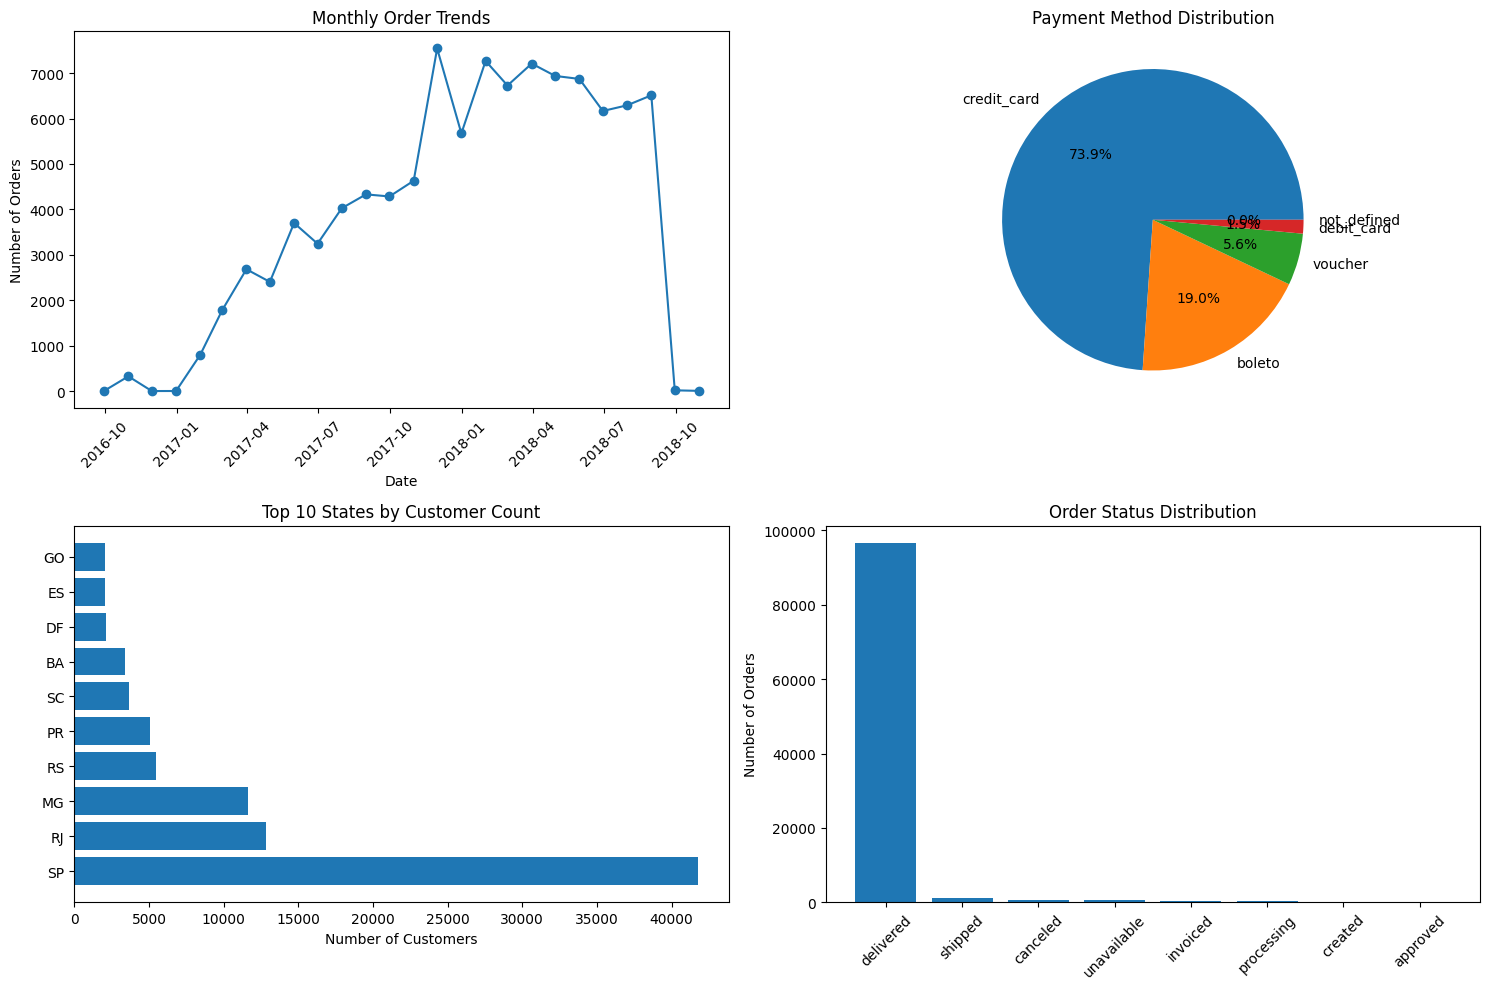


📊 RECOMMENDED DASHBOARD COMPONENTS:
   1. Executive Summary: KPI cards (total revenue, orders, customers)
   2. Sales Trends: Time series charts showing revenue and order volume
   3. Geographic Analytics: Maps showing sales by state/region
   4. Product Performance: Category analysis and top-selling products
   5. Customer Analytics: Acquisition, retention, and geographic distribution
   6. Operational Metrics: Delivery performance and order fulfillment
   7. Payment Analytics: Payment method trends and transaction values
   8. Seller Performance: Top sellers and geographic distribution


In [14]:
# Create sample visualizations for dashboard recommendations
def create_sample_visualizations():
    print("=" * 80)
    print("DASHBOARD VISUALIZATION RECOMMENDATIONS")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Order trends over time
    if 'orders_dataset' in datasets:
        orders = datasets['orders_dataset'].copy()
        if 'order_purchase_timestamp' in orders.columns:
            orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
            monthly_orders = orders.set_index('order_purchase_timestamp').resample('M').size()
            
            axes[0,0].plot(monthly_orders.index, monthly_orders.values, marker='o')
            axes[0,0].set_title('Monthly Order Trends')
            axes[0,0].set_xlabel('Date')
            axes[0,0].set_ylabel('Number of Orders')
            axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Payment method distribution
    if 'order_payments_dataset' in datasets:
        payments = datasets['order_payments_dataset'].copy()
        payment_dist = payments['payment_type'].value_counts()
        
        axes[0,1].pie(payment_dist.values, labels=payment_dist.index, autopct='%1.1f%%')
        axes[0,1].set_title('Payment Method Distribution')
    
    # 3. Geographic distribution
    if 'customers_dataset' in datasets:
        customers = datasets['customers_dataset'].copy()
        if 'customer_state' in customers.columns:
            state_dist = customers['customer_state'].value_counts().head(10)
            
            axes[1,0].barh(range(len(state_dist)), state_dist.values)
            axes[1,0].set_yticks(range(len(state_dist)))
            axes[1,0].set_yticklabels(state_dist.index)
            axes[1,0].set_title('Top 10 States by Customer Count')
            axes[1,0].set_xlabel('Number of Customers')
    
    # 4. Order status distribution
    if 'orders_dataset' in datasets:
        orders = datasets['orders_dataset'].copy()
        status_dist = orders['order_status'].value_counts()
        
        axes[1,1].bar(range(len(status_dist)), status_dist.values)
        axes[1,1].set_xticks(range(len(status_dist)))
        axes[1,1].set_xticklabels(status_dist.index, rotation=45)
        axes[1,1].set_title('Order Status Distribution')
        axes[1,1].set_ylabel('Number of Orders')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 RECOMMENDED DASHBOARD COMPONENTS:")
    dashboard_components = [
        "Executive Summary: KPI cards (total revenue, orders, customers)",
        "Sales Trends: Time series charts showing revenue and order volume",
        "Geographic Analytics: Maps showing sales by state/region", 
        "Product Performance: Category analysis and top-selling products",
        "Customer Analytics: Acquisition, retention, and geographic distribution",
        "Operational Metrics: Delivery performance and order fulfillment",
        "Payment Analytics: Payment method trends and transaction values",
        "Seller Performance: Top sellers and geographic distribution"
    ]
    
    for i, component in enumerate(dashboard_components, 1):
        print(f"   {i}. {component}")

create_sample_visualizations()

# 8. ETL Process Recommendations

Guidelines for building the ETL pipeline to populate your data warehouse.

In [23]:
# ETL process recommendations
def recommend_etl_process():
    print("=" * 80)
    print("ETL PROCESS RECOMMENDATIONS")
    print("=" * 80)
    
    print("🔄 EXTRACTION PHASE:")
    print("   • Source: CSV files from Olist dataset")
    print("   • Frequency: Historical load (one-time) + incremental updates")
    print("   • Data validation: Check file integrity and format consistency")
    
    print("\n🔧 TRANSFORMATION PHASE:")
    transformations = [
        "Data Cleansing:",
        "  - Handle missing values (imputation or exclusion rules)",
        "  - Remove duplicate records",
        "  - Standardize text fields (trim, case conversion)",
        "",
        "Data Type Conversions:",
        "  - Convert string dates to datetime objects", 
        "  - Ensure numeric fields have correct precision",
        "  - Validate and standardize geographic codes",
        "",
        "Business Rules:",
        "  - Create calculated fields (delivery time, order value)",
        "  - Apply business logic for order status transitions",
        "  - Generate surrogate keys for dimension tables",
        "",
        "Data Integration:",
        "  - Join related tables using foreign keys",
        "  - Resolve referential integrity issues",
        "  - Create slowly changing dimension logic"
    ]
    
    for transformation in transformations:
        print(f"   {transformation}")
    
    print("\n📥 LOADING PHASE:")
    loading_steps = [
        "Load dimension tables first (reference data)",
        "Validate dimension keys before loading facts",
        "Use bulk insert operations for large datasets",
        "Implement error handling and logging",
        "Create indexes after data loading",
        "Update statistics for query optimization"
    ]
    
    for i, step in enumerate(loading_steps, 1):
        print(f"   {i}. {step}")
    
    print(f"\n⚡ PERFORMANCE CONSIDERATIONS:")
    perf_tips = [
        "Partition fact tables by date for better query performance",
        "Create appropriate indexes on foreign keys and filter columns", 
        "Use columnstore indexes for analytical queries",
        "Implement incremental loading for ongoing updates",
        "Consider data compression to reduce storage costs",
        "Set up monitoring and alerting for ETL job failures"
    ]
    
    for i, tip in enumerate(perf_tips, 1):
        print(f"   {i}. {tip}")

recommend_etl_process()

ETL PROCESS RECOMMENDATIONS
🔄 EXTRACTION PHASE:
   • Source: CSV files from Olist dataset
   • Frequency: Historical load (one-time) + incremental updates
   • Data validation: Check file integrity and format consistency

🔧 TRANSFORMATION PHASE:
   Data Cleansing:
     - Handle missing values (imputation or exclusion rules)
     - Remove duplicate records
     - Standardize text fields (trim, case conversion)
   
   Data Type Conversions:
     - Convert string dates to datetime objects
     - Ensure numeric fields have correct precision
     - Validate and standardize geographic codes
   
   Business Rules:
     - Create calculated fields (delivery time, order value)
     - Apply business logic for order status transitions
     - Generate surrogate keys for dimension tables
   
   Data Integration:
     - Join related tables using foreign keys
     - Resolve referential integrity issues
     - Create slowly changing dimension logic

📥 LOADING PHASE:
   1. Load dimension tables first (r

# Summary

This comprehensive analysis provides the foundation for building an effective data warehouse for the Olist e-commerce dataset. The recommended star schema will support various analytical needs while maintaining good performance and data integrity.

## Next Steps:
1. **Design the physical data model** based on the recommended schema
2. **Implement the ETL pipeline** following the transformation guidelines
3. **Create the dashboard** with the suggested visualizations
4. **Set up monitoring** for data quality and pipeline performance
5. **Define data governance** policies for ongoing maintenance

# 9. Order Items Business Rules Validation

Validate the business rule that order_item_id represents sequential numbering of items within each order.

In [ ]:
# Validate order_item_id business rules
def validate_order_item_business_rules():
    print("=" * 80)
    print("ORDER ITEM BUSINESS RULES VALIDATION")
    print("=" * 80)
    
    if 'order_items_dataset' not in datasets:
        print("❌ Order items dataset not available")
        return
    
    items_df = datasets['order_items_dataset'].copy()
    
    # Rule 1: order_item_id should start from 1 for each order
    print("📋 RULE 1: Sequential numbering starts from 1")
    orders_start_from_1 = 0
    orders_not_start_from_1 = []
    
    for order_id in items_df['order_id'].unique():
        order_items = items_df[items_df['order_id'] == order_id]['order_item_id'].sort_values()
        if order_items.iloc[0] == 1:
            orders_start_from_1 += 1
        else:
            orders_not_start_from_1.append((order_id, order_items.iloc[0]))
    
    print(f"   ✅ Orders starting from 1: {orders_start_from_1:,}")
    print(f"   ❌ Orders not starting from 1: {len(orders_not_start_from_1):,}")
    if orders_not_start_from_1[:3]:
        print(f"   Sample violations: {orders_not_start_from_1[:3]}")
    
    # Rule 2: No gaps in sequential numbering
    print(f"\n📋 RULE 2: No gaps in sequential numbering")
    orders_with_gaps = 0
    gap_examples = []
    
    for order_id in items_df['order_id'].unique():
        order_items = items_df[items_df['order_id'] == order_id]['order_item_id'].sort_values().tolist()
        expected_sequence = list(range(1, len(order_items) + 1))
        if order_items != expected_sequence:
            orders_with_gaps += 1
            if len(gap_examples) < 3:
                gap_examples.append((order_id, order_items, expected_sequence))
    
    print(f"   ✅ Orders with perfect sequencing: {items_df['order_id'].nunique() - orders_with_gaps:,}")
    print(f"   ❌ Orders with gaps/issues: {orders_with_gaps:,}")
    if gap_examples:
        print(f"   Sample gap issues:")
        for order_id, actual, expected in gap_examples:
            print(f"     Order {order_id}: actual={actual}, expected={expected}")
    
    # Rule 3: order_item_id represents item sequence within order
    print(f"\n📋 RULE 3: Business interpretation validation")
    
    # Analyze relationship with other fields
    correlation_analysis = items_df.groupby(['order_id', 'order_item_id']).agg({
        'product_id': 'count',
        'price': 'mean',
        'freight_value': 'mean'
    }).reset_index()
    
    print(f"   Each (order_id, order_item_id) combination should be unique")
    duplicate_combinations = correlation_analysis[correlation_analysis['product_id'] > 1]
    print(f"   ✅ Unique combinations: {len(correlation_analysis) - len(duplicate_combinations):,}")
    print(f"   ❌ Duplicate combinations: {len(duplicate_combinations):,}")
    
    # Summary and recommendations
    print(f"\n🎯 BUSINESS RULE SUMMARY:")
    total_orders = items_df['order_id'].nunique()
    compliant_orders = total_orders - orders_with_gaps - len(orders_not_start_from_1)
    compliance_rate = (compliant_orders / total_orders) * 100
    
    print(f"   Total Orders Analyzed: {total_orders:,}")
    print(f"   Fully Compliant Orders: {compliant_orders:,}")
    print(f"   Compliance Rate: {compliance_rate:.2f}%")
    
    if compliance_rate < 95:
        print(f"\n⚠️  RECOMMENDATION: Data quality issues detected in order_item_id")
        print(f"   - Consider data cleansing in ETL process")
        print(f"   - Implement validation rules")
        print(f"   - Generate corrected sequential numbering if needed")
    else:
        print(f"\n✅ RECOMMENDATION: order_item_id follows business rules adequately")

validate_order_item_business_rules()

# 10. Timestamp Data Quality Analysis

Analyze the quality of timestamp fields and recommend handling strategies.

In [ ]:
# Analyze timestamp data quality for ETL design
def analyze_timestamp_quality():
    print("=" * 80)
    print("TIMESTAMP DATA QUALITY ANALYSIS")
    print("=" * 80)
    
    if 'orders_dataset' not in datasets:
        print("❌ Orders dataset not available")
        return
    
    orders_df = datasets['orders_dataset'].copy()
    
    # Convert timestamp columns
    timestamp_columns = [
        'order_purchase_timestamp',
        'order_approved_at', 
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
    
    print("📅 TIMESTAMP COLUMNS ANALYSIS:")
    
    for col in timestamp_columns:
        if col in orders_df.columns:
            # Convert to datetime
            orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')
            
            # Calculate missing values
            total_count = len(orders_df)
            missing_count = orders_df[col].isna().sum()
            valid_count = total_count - missing_count
            missing_percentage = (missing_count / total_count) * 100
            
            print(f"\n   {col}:")
            print(f"     Total records: {total_count:,}")
            print(f"     Valid timestamps: {valid_count:,} ({100-missing_percentage:.1f}%)")
            print(f"     Missing/Invalid: {missing_count:,} ({missing_percentage:.1f}%)")
            
            if valid_count > 0:
                print(f"     Date range: {orders_df[col].min()} to {orders_df[col].max()}")
    
    print("\n🔧 RECOMMENDED ETL STRATEGY:")
    strategies = [
        "1. Allow NULL values in database schema for optional timestamps",
        "2. Fill missing order_approved_at with purchase_timestamp + 2 hours",
        "3. Fill missing carrier_date with approved_at + 2 days", 
        "4. Fill missing customer_date with estimated_date or purchase + 10 days",
        "5. Fill missing estimated_date with purchase + 15 days",
        "6. Add flags to track which timestamps were artificially filled",
        "7. Use business logic for realistic timestamp progression"
    ]
    
    for strategy in strategies:
        print(f"     {strategy}")
    
    print("\n📊 BUSINESS LOGIC VALIDATION:")
    
    # Check timestamp progression logic
    valid_progression = 0
    total_with_timestamps = 0
    
    for _, row in orders_df.iterrows():
        purchase = row['order_purchase_timestamp']
        approved = row['order_approved_at']
        delivered = row['order_delivered_customer_date']
        
        if pd.notna(purchase) and pd.notna(approved) and pd.notna(delivered):
            total_with_timestamps += 1
            
            # Check if progression makes sense: purchase <= approved <= delivered
            if purchase <= approved <= delivered:
                valid_progression += 1
    
    if total_with_timestamps > 0:
        progression_rate = (valid_progression / total_with_timestamps) * 100
        print(f"     Orders with valid timestamp progression: {valid_progression:,}/{total_with_timestamps:,} ({progression_rate:.1f}%)")
    
    print(f"\n✅ CONCLUSION: Use nullable timestamps with business-logic defaults")

analyze_timestamp_quality()